<a href="https://colab.research.google.com/github/kenzoyanome/forced_landing_experiment/blob/main/Proyecto_Landing_Experiment_mod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from scipy.stats                  import pointbiserialr, chi2_contingency, ttest_ind, levene
from statsmodels.stats.proportion import proportions_ztest

import warnings                                                  # MANEJO DE WARNINGS - ADVERTENCIAS
warnings.filterwarnings('ignore', category=FutureWarning)        # IGNORAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                       # ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                          # ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)                      # AUTOAJUSTA ANCHO DE COLUMNAS
pd.set_option('display.float_format', lambda x: '%.3f' % x)      # PERMITE EVADIR EL MOSTRAR NÚMEROS CON NOTACIÓN CINETÍFICA
plt.rcParams['figure.dpi'] = 140                                 # NIVEL DE RESOLUCIÓN.

In [ ]:
# cargar archivo
df = pd.read_csv("/datasets/landing_experiment.csv")

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.080
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.000
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.000
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.000
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.000


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:  
- No se observan valores nulos ni ausentes en ninguna de las 9 columnnas.
- La columna `date` es de tipo de dato (object) y debería de ser datetime.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id`        - Identificador único del usuario
- `date`           - Fecha en la que el usuario fue expuesto a la página
- `landing`        - Versión de la página mostrada al usuario
- `region`         - Región geográfica del usuario
- `dispositivo`    - Tipo de dispositivo utilizado por el usuario
- `traffic_source` - Canal por el que llegó el usuario
- `user_type`      - Tipo de usuario según historial previo
- `converted`      - Indica si el usuario realizó una conversión
- `gasto`          - Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Convertir a datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count   40000.000
mean        9.326
std        25.668
min         0.000
25%         0.000
50%         0.000
75%         0.000
max       303.680
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count   40000.000
mean        0.143
std         0.350
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("Conteo de categorías:")
print(df["landing"].value_counts())

Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


In [ ]:
categoricas = ["landing", "region", "dispositivo", "traffic_source", "user_type", "converted"]
for col in categoricas:
    print(f"-----\nConteo de categorias {col}:")
    print(df[col].value_counts())

-----
Conteo de categorias landing:
B    20018
A    19982
Name: landing, dtype: int64
-----
Conteo de categorias region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
-----
Conteo de categorias dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
-----
Conteo de categorias traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
-----
Conteo de categorias user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
-----
Conteo de categorias converted:
0    34294
1     5706
Name: converted, dtype: int64


✍️ **Comentario**:  
- Todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df['converted'] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df['converted'] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
print("Gasto  promedio grupo A:")
print(gasto_A.mean())
print("Gasto  promedio grupo B:")
print(gasto_B.mean())

Gasto  promedio grupo A:
61.0865724522293
Gasto  promedio grupo B:
68.74536005009392


### Prueba t-test
**Hipotesis:**
- **Hipotesis nula (H₀):** El gasto promedio de los clientes es igual en la pagina A y en la pagina B
- **Hipotesis alternativa (H₁):** Existe diferencia significativa en el gasto promedio entre paginas A y B

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A,  gasto_B)
# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: Existe diferencia significativa en el gasto promedio entre paginas A y B")
else:
    print("No rechazamos la hipótesis nula: El gasto promedio de los clientes es igual en la pagina A y en la pagina B")

Rechazamos la hipótesis nula: Existe diferencia significativa en el gasto promedio entre paginas A y B


In [ ]:
print(f"La media para gasto_A es: {gasto_A.mean():.4f}")
print(f"La media para gasto_B es: {gasto_B.mean():.4f}")
print(f"La diferencia es de: {(gasto_B.mean())-(gasto_A.mean()):.4f}")

La media para gasto_A es: 61.0866
La media para gasto_B es: 68.7454
La diferencia es de: 7.6588


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: Existe diferencia significativa en el gasto promedio entre paginas A y B

**Interpretación de negocio:**  
Los resultados de la t-test no implican causalidad automatica. Solo hemos comprobado una diferencia significativa estadisticamente hablando, sin embargo tendriamos que realizar comparaciones con la tasa de conversion para obtener un resultado mas concluyente

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z-test

**Hipotesis:**
- **Hipotesis nula (H₀):** La tasa de conversion es igual en ambas paginas. Cualquier diferencia se debe al azar del muestreo
- **Hipotesis alternativa (H₁):** La tasa de conversion es diferente entre ambas paginas. Hay un factor que influye en la decision de compra

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
exitos = [conversiones['A'], conversiones['B']]
print(exitos)
observaciones = [totales['A'], totales['B']]
print(observaciones)

[2512, 3194]
[19982, 20018]


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")
print()
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretacion

**Decision:**  
Rechazamos la hipotesis nula

**Interpretacion de negocio:**  
Los resultados de la z-test no implican causalidad automatica. La prueba nos muestra una diferencia en conversion entre la pagina A y la pagina B estadisticamente significativa, se puede afirmar que las tasas de conversion no son iguales.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi-square

**Hipótesis:**  
- **Hipótesis nula (H₀):** No existe relacion entre las dos variables (son independientes)
- **Hipótesis alternativa (H₁):** Si existe una relacion entre las dos variables (no son independientes)

In [ ]:
print(df[['traffic_source', 'converted']].value_counts())
print(pd.crosstab( df["traffic_source"], df["converted"], normalize='index')*100)

traffic_source  converted
Organic         0            15507
Ads             0            10176
Email           0             5205
Referral        0             3406
Organic         1             2480
Ads             1             1759
Email           1              918
Referral        1              549
dtype: int64
converted           0      1
traffic_source              
Ads            85.262 14.738
Email          85.007 14.993
Organic        86.212 13.788
Referral       86.119 13.881


In [ ]:
# Aplicar prueba
tabla1 = pd.crosstab(df["traffic_source"], df["converted"])
print(tabla1)
print('---'*10)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla1)
print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor P: {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549
------------------------------
Estadístico chi-cuadrado: 8.6621
Valor P: 0.0341
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [ ]:
if p_value < alpha:
    print("Rechazamos la hipotesis nula: hay evidencia de asociacion entre las variables")
else:
    print("No rechazamos la hipotesis nula: no hay evidencia suficiente de asociacion entre las variables")

Rechazamos la hipotesis nula: hay evidencia de asociacion entre las variables


### 📝 Conclusión e interpretación

**Decisión:**  
Podemos estar seguros de rechazar la hipotesis nula

**Interpretación de negocio:**  
Los datos proporcionan evidencia suficiente para afirmar que las variables no son independientes.  
Aun cuando la conversion este asociada al dispositivo no prueba que:
- El tipo de dispositivo cause la conversion.  
- No existan variables externas que impacten (`user_type` u otras)

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-square

**Hipótesis:**  
- **Hipótesis nula (H₀):** No existe relacion entre las dos variables (son independientes)  
- **Hipótesis alternativa (H₁):** Si existe una relacion entre las dos variables (no son independientes)

In [ ]:
print(df[['user_type', 'converted']].value_counts())
print(pd.crosstab( df["user_type"], df["converted"], normalize='index')*100)

user_type   converted
Nuevo       0            22295
Recurrente  0            11999
Nuevo       1             3738
Recurrente  1             1968
dtype: int64
converted       0      1
user_type               
Nuevo      85.641 14.359
Recurrente 85.910 14.090


In [ ]:
# Aplicar prueba
tabla2 = pd.crosstab(df["user_type"], df["converted"])
print(tabla2)
print('---'*10)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)
print(f"Estadístico chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor P: {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968
------------------------------
Estadístico chi-cuadrado: 0.5135
Valor P: 0.4736
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [ ]:
if p_value < alpha:
    print("Rechazamos la hipotesis nula: hay evidencia de asociacion entre las variables")
else:
    print("No rechazamos la hipotesis nula: no hay evidencia suficiente de asociacion entre las variables")

No rechazamos la hipotesis nula: no hay evidencia suficiente de asociacion entre las variables


### 📝 Conclusión e interpretación

**Decision:**  
No rechazamos la hipotesis nula (p_value = 0.4736 > 0.05). No existe asociacion estadisticamente significativa entre el tipo de usuario y la tasa de conversion

**Interpretacion de negocio:**  
La tasa de conversion es estadisticamente similar entre usuarios Nuevos (14.36%) y Recurrentes (14.09%). La diferencia de apenas 0.27 puntos porcentuales puede ser atribuible al azar, no a una relacion real entre el tipo de usuario y la conversion.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

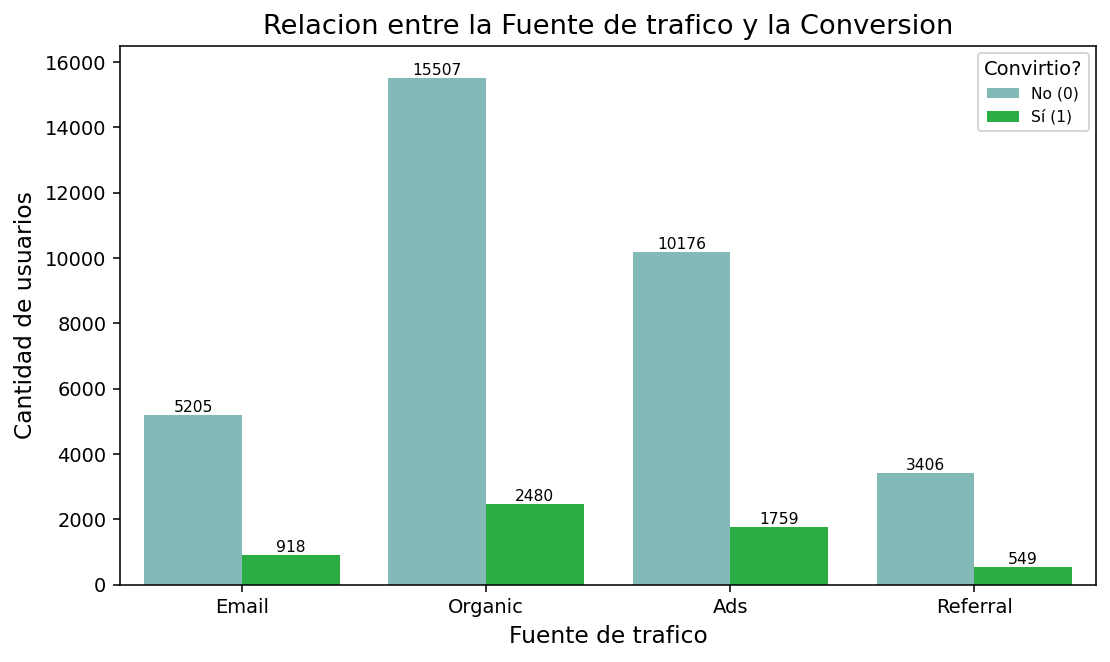

In [ ]:
# Cantidad absoluta de conversiones
# Grafico de barras agrupadas
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette=['#7AC2BF','#16C235'])
# Agregar valores
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2,
            y=height,
            s=height,
            ha='center',
            va='bottom',
            fontsize=8)
# Añadir detalles
plt.title('Relacion entre la Fuente de trafico y la Conversion', fontsize=14)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,16500)
plt.legend(title='Convirtio?', labels=['No (0)', 'Sí (1)'], fontsize=8)
ax.tick_params(axis='both', labelsize=10)
plt.show()

✍️ **Comentarios**:  
- Organic es la fuente con mayor volumen de usuarios y conversiones absolutas.  
- Email presenta la mayor tasa de conversión relativa (~15%).  
- Referral muestra el menor volumen en todas las categorias.

In [ ]:
tabla1a = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100

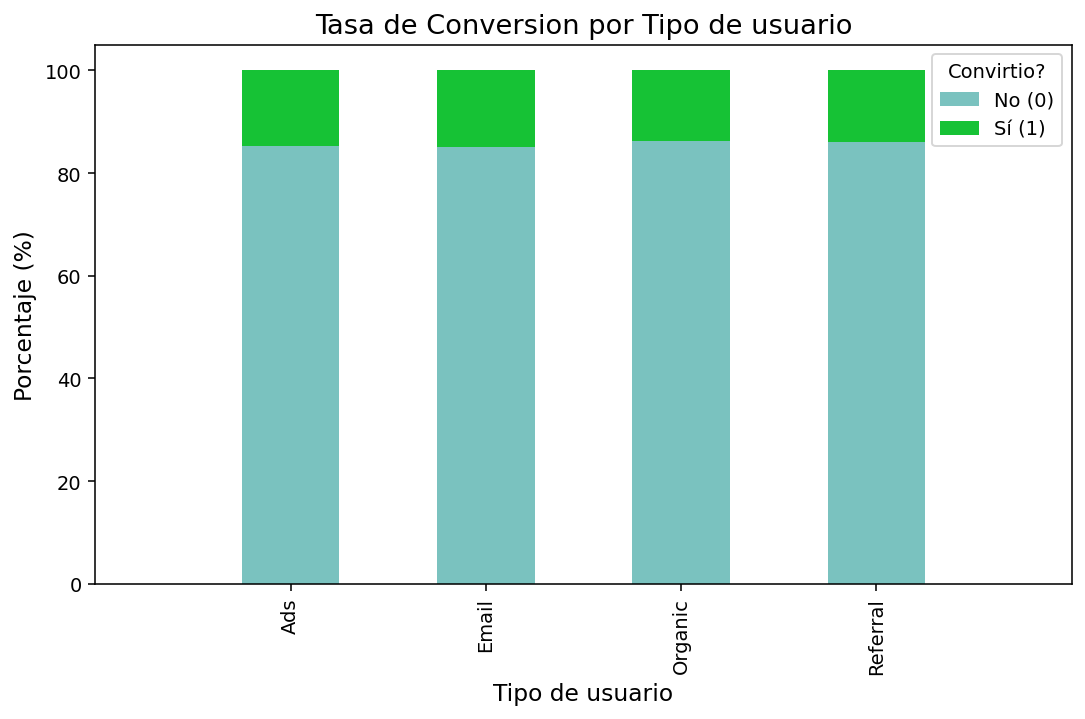

In [ ]:
# Proporcion de conversion de usuarios
# Grafico de barras apiladas
ax = tabla1a.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#7AC2BF','#16C235'])
plt.title('Tasa de Conversion por Tipo de usuario', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='Convirtio?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

✍️ **Comentarios**:  
- Las 4 fuentes de trafico presentan tasas de conversion muy similares, oscilando entre el 14% y 15%.
- Email muestra una ligera ventaja relativa, mientras que Organic y Referral tienen tasas marginalmente menores.
- La homogeneidad entre fuentes sugiere que el canal de origen no determina la probabilidad de conversion.

### Relación entre el tipo de usuario y la conversión

In [ ]:
tabla2a = pd.crosstab(df['user_type'], df['converted'], normalize='index')*100

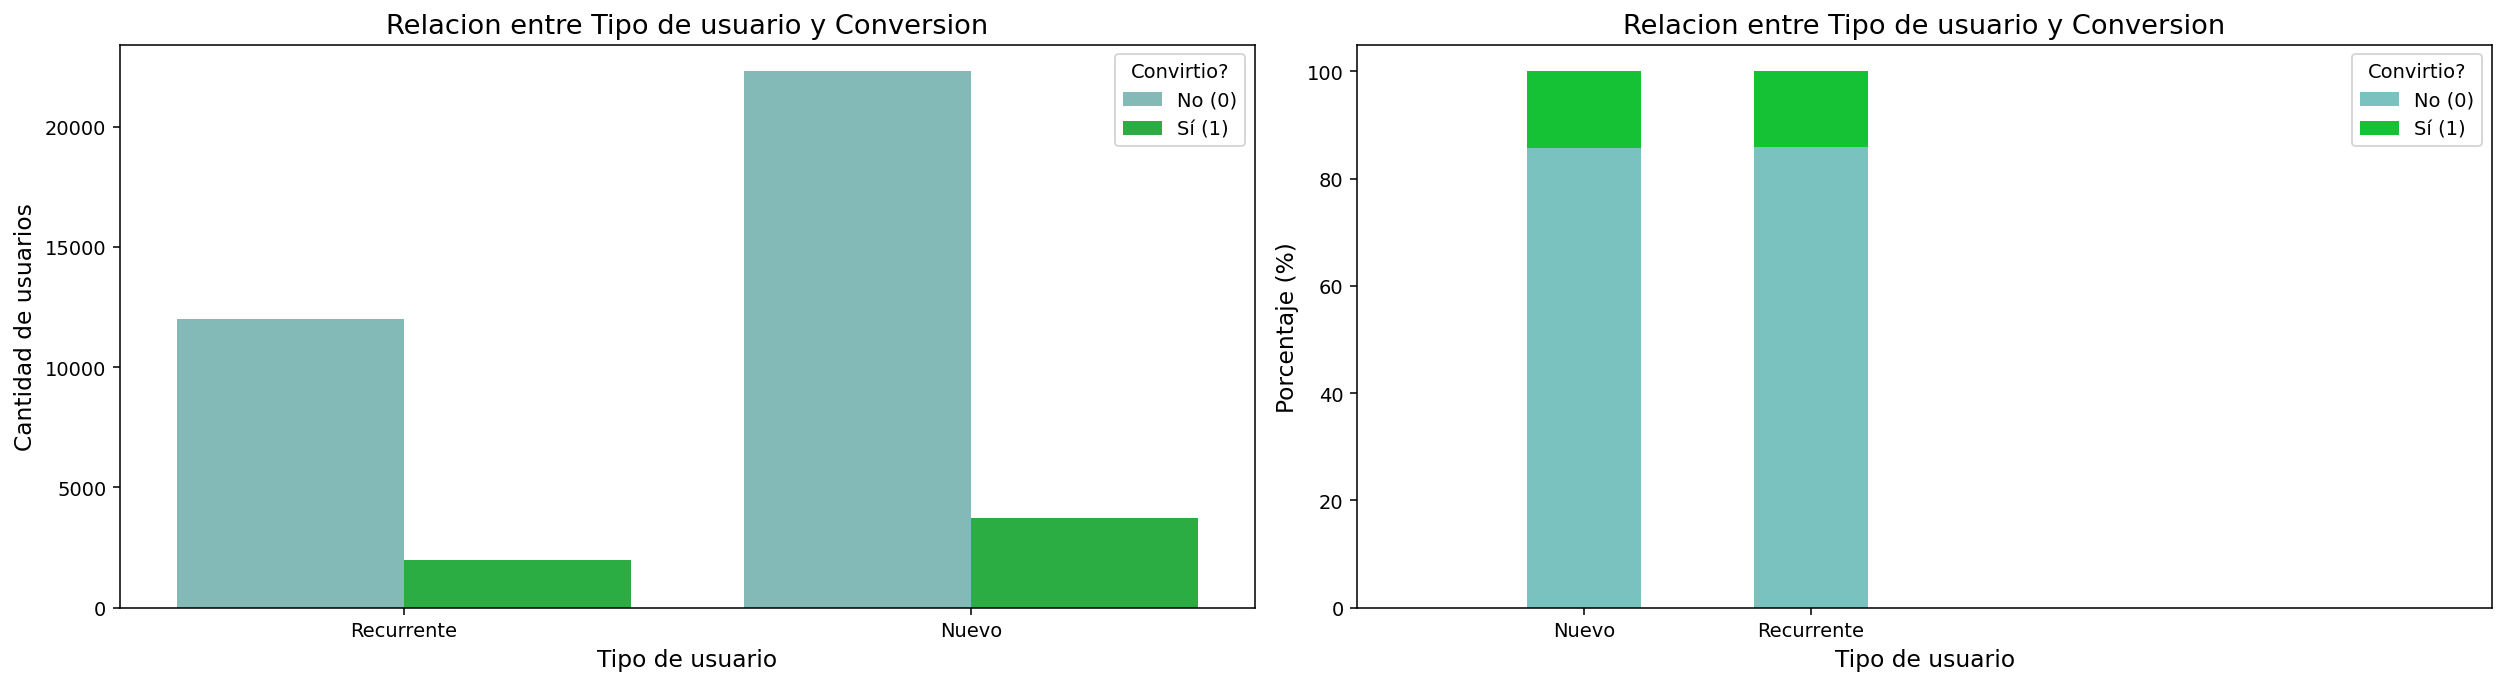

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Barras agrupadas
sns.countplot(data=df, x='user_type', hue='converted', palette=['#7AC2BF','#16C235'], ax=axes[0])
axes[0].set_title('Relacion entre Tipo de usuario y Conversion', fontsize=14)
axes[0].set_xlabel('Tipo de usuario', fontsize=12)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[0].legend(title='Convirtio?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
tabla2a.plot(kind='bar', stacked=True, color=["#7AC2BF", "#16C235"], ax=axes[1])
axes[1].set_title('Relacion entre Tipo de usuario y Conversion', fontsize=14)
axes[1].set_xlabel('Tipo de usuario', fontsize=12)
axes[1].set_ylabel('Porcentaje (%)', fontsize=12)
axes[1].set_xlim(-1, 4)
axes[1].legend(title='Convirtio?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

✍️ **Comentarios**:  
- El grafico izquierdo muestra que hay mas usuarios Nuevos en terminos absolutos, con mayor volumen de conversiones.
- Sin embargo, el grafico derecho revela que la tasa de conversión es practicamente identica (~14%) en ambos segmentos.
- Esto confirma que el tipo de usuario no determina la probabilidad de conversion.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparacion de pagina (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La pagina B genera un gasto promedio significativamente mayor que la pagina A entre los usuarios convertidos
- La diferencia es estadisticamente significativa (t-test, p < 0.05), lo que descarta que sea producto del azar
- **Interpretación:**  La pagina B no solo atrae conversiones, sino que los usuarios que convierte tienen mayor disposicion de gastar, lo que la hace mas valiosa desde una perspectiva de ingreso por cliente

**Tasa de conversion:**
- La pagina B presenta una tasa de conversion superior a la pagina A
- La diferencia es estadisticamente significativa (z-test, p < 0.05), confirmando que no es aleatoria.
- **Interpretacion:** La pagina B convierte a mas usuarios y con mayor gasto promedio, consolidandose como una version superior en ambas metricas clave del experimento
---

#### 📊 **Segmentación por fuente de trafico**
- Organic concentra el mayor volumen de usuarios y conversiones absolutas
- Email, aunque con menor volumen, presenta la tasa de conversion relativa mas alta (~15%)
- Referral es el canal con menor presencia en todas las categorias
- **Interpretacion:** La fuente de trafico si esta asociada a la conversion (chi-cuadrado, p < 0.05). Los canales Email y Organic son los mas eficientes y deben priorizarse en la estrategia de adquisicion.
---

#### 📊 **Segmentacion por tipo de usuario**
- Las tasas de conversion de usuarios Nuevos (14.36%) y Recurrentes (14.09%) son practicamente identicas, sin diferencia estadisticamente significativa (chi-cuadrado, p = 0.4736)
- **Interpretacion:** El historial del usuario no influye en la probabilidad de conversion. Tratar diferencialmente a ambos segmentos en campañas de conversion no esta justificado por los datos
---

Las visualizaciones usadas respaldan los resultados estadisticos de pasos anteriores.
---

#### 💡 **Recomendaciones de negocio:**
- Implementar la pagina B como version definitiva, ya que supera a la pagina A tanto en tasa de conversion como en gasto promedio por cliente convertido
- Invertir en los canales Email y Organic, dado que son los que muestran mayor efectividad relativa en conversion; evaluar si escalar Referral tiene retorno suficiente dado su bajo volumen.
- No segmentar campañas por tipo de usuario (Nuevo vs Recurrente) para objetivos de conversion, ya que ambos responden de manera estadisticamente igual; redirigir esos esfuerzos a variables que si discriminan, como la fuente de trafico.
- Realizar un seguimiento post-implementacion de la pagina B para confirmar que los resultados del experimento se mantienen en produccion a escala real.